# Prueba Técnica - Voice of Customer (VoC), NLP & IA Generativa en Cobranzas

## 🎯 Objetivo de la prueba
Analizar la **Base Suministrada y Anonimizada/Sintética de Conversaciones** (42,607 interacciones / 1,197 conversaciones) de WhatsApp mediante **IA Generativa y NLP Granular** para:
1. **Extracción Estructurada de Variables (Schema de IA)**: Clasificar semánticamente causas de no pago, ofertas del asesor, argumentos persuasivos, nivel de acuerdo y tono emocional del cliente.
2. **Criterio Estricto de Acuerdo de Pago**: Únicamente se considera acuerdo si el cliente manifiesta explícitamente su compromiso de pago indicando una **fecha específica** (día/mes o día de semana).
3. **Respuestas a Preguntas de Negocio (A, B, C, D, E)**:
   - **A**: ¿Cuáles son los principales motivos de no pago?
   - **B**: ¿Qué ofertas realizan los asesores para lograr un acuerdo de pago?
   - **C**: ¿Qué ofrecimientos o argumentos del asesor logran más acuerdos de pago?
   - **D**: ¿Qué está pasando en las conversaciones? (Resumen estructurado de cada una).
   - **E**: ¿Qué características tienen las conversaciones con menor satisfacción? (Top 5 peores, factores de fricción y recomendaciones).
4. **Propuesta Arquitectónica RAG & Metodologías Analíticas**: Estandarización de respuestas mediante Retrieval-Augmented Generation, base de conocimiento curada, guardrails y 5 metodologías avanzadas.


## 1. Importación de Librerías y Configuración del Entorno

In [ ]:
import sys
import io
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

import re
import json
from pathlib import Path
from collections import Counter
from datetime import datetime
from dateutil import parser as date_parser

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 300
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", None)

print("[OK] Entorno y librerias cargadas correctamente.")

## 2. Ingesta de la Base Suministrada y Anonimizada/Sintética (42,607 interacciones)

Carga y estructuración del archivo `Base sintetica conversaciones.xlsx`, mapeando los roles (`CLIENTE`, `ASESOR`, `BOT`, `HSM`) e identificando las respuestas a encuestas de satisfacción (`csat_encuesta` en escala 1-7 y 0-10).


In [ ]:
excel_path = Path("Base sintetica conversaciones.xlsx")
if not excel_path.exists():
    excel_path = Path("data/Base sintetica conversaciones.xlsx")
    
if not excel_path.exists():
    raise FileNotFoundError("No se encontro Base sintetica conversaciones.xlsx")

df_raw = pd.read_excel(excel_path)
print(f"[DATA] Base real cargada: {len(df_raw)} mensajes en {df_raw['uk_id_conversacion'].nunique()} conversaciones.")

role_map = {"USUARIO": "cliente", "AGENTE": "asesor", "BOT": "bot", "HSM": "plantilla_hsm"}
df_raw["speaker_role"] = df_raw["de"].map(lambda x: role_map.get(str(x).upper(), "otro"))

df_raw.head(8)

## 3. Pipeline de IA Generativa Multi-Modelo - Clasificación Semántica Real

Este módulo implementa una arquitectura resiliente multi-proveedor liderada por **Ollama Cloud (gemma4:31b-cloud)** como motor principal, con fallbacks automáticos a **Groq (GPT-OSS 20B / Qwen)** y **Google Gemini (Gemini 3.5 Flash Lite)**.

### ¿Por qué IA Generativa en lugar de Expresiones Regulares?
| Limitación del regex / heurística | Solución con IA Generativa |
|---|---|
| `'ya pagué pero sigue en mora'` -> falso positivo `pago_ya_realizado` | LLM detecta contexto real -> `disputa_saldo_o_cobro` |
| `'ando en la olla'` o `'estoy ilíquido'` -> sin clasificar | LLM entiende modismos -> `falta_liquidez` |
| Acuerdo sin fecha marcado erróneamente como acuerdo | LLM aplica regla estricta: intención + fecha puntual = acuerdo |
| Incapacidad de medir tono emocional | LLM clasifica: `frustrado`, `indignado`, `colaborativo`, `evasivo` |


In [ ]:
import os, re, time, json as _json
from urllib import error as urlerror
from urllib import request as urlrequest
import numpy as np
from dotenv import load_dotenv
from groq import Groq
from google import genai
from google.genai import types

# Cargar variables de entorno
load_dotenv()

# ── 1. MOTOR PRINCIPAL: OLLAMA CLOUD ─────────────────────────────────────────
OLLAMA_URL = os.getenv('OLLAMA_URL', 'http://127.0.0.1:11434/api/chat')
OLLAMA_MODELS = ('gemma4:31b-cloud',)
OLLAMA_MODELS = ('gemma4:31b-cloud',)
OLLAMA_MODEL_NAME = 'gemma4:31b-cloud'
OLLAMA_TIMEOUT_S = int(os.getenv('OLLAMA_TIMEOUT_S', '180'))
OLLAMA_AVAILABLE = True
print(f'[OK] MOTOR PRINCIPAL: Ollama Cloud / {OLLAMA_MODEL_NAME} ({OLLAMA_URL})')

# ── 2. FALLBACK 1: GROQ ──────────────────────────────────────────────────────
GROQ_API_KEY = os.getenv('GROQ_API_KEY', '')
if GROQ_API_KEY and GROQ_API_KEY != 'PEGA_TU_API_KEY_AQUI':
    MODEL_NAME = 'openai/gpt-oss-20b'
    groq_client = Groq(api_key=GROQ_API_KEY, max_retries=0)
    print(f'[OK] Fallback 1: Groq / {MODEL_NAME}')
else:
    groq_client = None
    print('[INFO] Fallback 1 Groq: no configurado')

# ── 3. FALLBACK 2: GOOGLE GEMINI ─────────────────────────────────────────────
GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY', '')
if GOOGLE_API_KEY and GOOGLE_API_KEY != 'PEGA_TU_API_KEY_AQUI':
    GEMINI_MODEL_NAMES = ('gemini-3.5-flash-lite', 'gemini-3.1-flash-lite', 'gemini-3.6-flash', 'gemini-3.5-flash')
    GEMINI_MODEL_NAME = GEMINI_MODEL_NAMES[0]
    gemini_client = genai.Client(
        api_key=GOOGLE_API_KEY,
        http_options=types.HttpOptions(timeout=45000, retry_options={'attempts': 1}),
    )
    print(f"[OK] Fallback 2: Gemini ({' -> '.join(GEMINI_MODEL_NAMES)})")
else:
    gemini_client = None
    print('[INFO] Fallback 2 Gemini: no configurado')

SYSTEM_PROMPT = '''Eres un analista experto en Voice of Customer (VoC) especializado
en operaciones de cobranza bancaria por WhatsApp en America Latina.

REGLAS CRITICAS:
1. motivos_no_pago SOLO de lo que el CLIENTE dijo explicitamente.
   NO inferas motivos de mensajes del ASESOR, BOT o HSM.
2. acuerdo_pago = 1 UNICAMENTE si el CLIENTE expresa intencion de pago Y
   menciona una fecha especifica (dia/mes o dia de la semana).
   Solo 'voy a pagar' sin fecha -> acuerdo_pago = 0.
3. Si cliente dice 'ya pague' o similar -> motivos incluye pago_ya_realizado
   y requiere_escalamiento = true. NO insistir en cobro.
4. Disputa o cliente no reconoce deuda -> requiere_escalamiento = true.
5. Sin motivo explicito del cliente -> motivos_no_pago = [desconexion_o_rebote].
6. Responde UNICAMENTE con JSON valido. Sin texto extra. Sin markdown.

TAXONOMIA DE MOTIVOS (usa solo estas categorias en la lista):
  desconexion_o_rebote | falta_liquidez | pago_ya_realizado
  priorizacion_otros_gastos | desempleo | salud
  disputa_saldo_o_cobro | consulta_o_tramite | emergencia_familiar

TAXONOMIA DE OFERTAS (usa solo estas):
  descuento | fraccionamiento | extension_plazo
  condonacion_intereses | refinanciacion | derivacion_reclamos

TAXONOMIA DE ARGUMENTOS (usa solo estos):
  evitar_reporte | evitar_gastos | beneficio_inmediato | empatia_y_apoyo
'''

OUTPUT_SCHEMA = {
    '$schema': 'http://json-schema.org/draft-07/schema',
    'title': 'AnalisisConversacionCobranza',
    'type': 'object',
    'required': ['motivos_no_pago', 'acuerdo_pago', 'requiere_escalamiento',
                 'resumen_conversacion', 'score_riesgo_cx'],
    'properties': {
        'motivos_no_pago': {
            'type': 'array', 'items': {'type': 'string'},
            'description': 'Motivos expresados EXPLICITAMENTE por el CLIENTE'
        },
        'submotivo': {'type': 'string', 'description': 'Descripcion con las palabras del cliente'},
        'ofertas_asesor': {'type': 'array', 'items': {'type': 'string'}},
        'argumentos_asesor': {'type': 'array', 'items': {'type': 'string'}},
        'acuerdo_pago': {
            'type': 'integer', 'enum': [0, 1],
            'description': '1 SOLO si cliente da intencion + fecha especifica'
        },
        'fecha_compromiso': {'type': ['string', 'null']},
        'tono_cliente': {
            'type': 'string',
            'enum': ['colaborativo', 'neutral', 'frustrado', 'indignado', 'evasivo']
        },
        'tono_asesor': {
            'type': 'string',
            'enum': ['empatico', 'neutral', 'presionador', 'ineficaz']
        },
        'requiere_escalamiento': {
            'type': 'boolean',
            'description': 'true si hay disputa, pago ya realizado o cobro erroneo'
        },
        'resumen_conversacion': {
            'type': 'string',
            'description': 'Resumen en 2-3 oraciones: contexto | objecion | resultado'
        },
        'score_riesgo_cx': {
            'type': 'integer', 'minimum': 0, 'maximum': 10,
            'description': '10=muy alto riesgo de mala experiencia, 0=sin riesgo'
        }
    }
}

print('[OK] System Prompt y JSON Schema configurados.')
print(f'     {len(OUTPUT_SCHEMA["properties"])} campos de salida estructurada.')

In [ ]:
import threading

MAX_COMPLETION_TOKENS = 1500  # Margen para reasoning low y una respuesta JSON completa.
MAX_COMPLETION_TOKENS_BY_MODEL = {
    'openai/gpt-oss-20b': 1500,
    'qwen/qwen3.8-27b': 800,  # Limite OTPM de Qwen: 1,000; deja margen para su respuesta JSON.
}
MIN_REQUEST_INTERVAL_S = 35  # Espacio entre solicitudes del mismo modelo para respetar su TPM.
# el reasoning consume todo el presupuesto y el contenido llega vacio (finish_reason='length')

class GroqRateLimitedClient:
    '''Controla la cuota y normaliza JSON no estricto de GPT-OSS en Groq.'''
    def __init__(self, client):
        self._client = client
        self._cooldown_lock = threading.Lock()
        self._cooldown_until_by_model = {}
        self._next_request_at_by_model = {}

    @property
    def chat(self):
        return self

    @property
    def completions(self):
        return self

    def create(self, **kwargs):
        model_name = str(kwargs.get('model', ''))
        kwargs.setdefault('max_completion_tokens', MAX_COMPLETION_TOKENS_BY_MODEL.get(model_name, MAX_COMPLETION_TOKENS))
        if 'gpt-oss' in str(kwargs.get('model', '')):
            kwargs.setdefault('reasoning_effort', 'low')
        with self._cooldown_lock:
            now = time.monotonic()
            scheduled_at = max(now, self._cooldown_until_by_model.get(model_name, 0.0), self._next_request_at_by_model.get(model_name, 0.0))
            self._next_request_at_by_model[model_name] = scheduled_at + MIN_REQUEST_INTERVAL_S
            wait = scheduled_at - now
        if wait > 0:
            time.sleep(wait)
        try:
            response = self._client.chat.completions.create(**kwargs)
        except Exception as error:
            retry_after = re.search(r'try again in (?:(\d+)m)?([\d.]+)s', str(error), flags=re.IGNORECASE)
            if retry_after:
                with self._cooldown_lock:
                    retry_seconds = int(retry_after.group(1) or 0) * 60 + float(retry_after.group(2)) + 1
                    self._cooldown_until_by_model[model_name] = max(self._cooldown_until_by_model.get(model_name, 0.0), time.monotonic() + retry_seconds)
            raise

        choice = response.choices[0]
        content = (choice.message.content or '').strip()
        content = re.sub(r'<think>.*?</think>', '', content, flags=re.DOTALL).strip()
        content = re.sub(r'^```(?:json)?\s*|\s*```$', '', content).strip()
        match = re.search(r'\{.*\}\s*$', content, flags=re.DOTALL)
        if not match:
            raise ValueError(
                f'Respuesta vacia o sin JSON valido del modelo '
                f'(finish_reason={choice.finish_reason}, content_len={len(content)}).'
            )
        response.choices[0].message.content = match.group(0)
        return response


groq_client = GroqRateLimitedClient(groq_client)
print('[OK] Modo JSON forzado (json_object), reasoning_effort=low y maximo de 1500 tokens activados.')

## 4. Ejecución del Pipeline LLM Concurrente (Groq analiza cada conversación)

> **Configuración de `SAMPLE_N`**:
> - `SAMPLE_N = 10` -> prueba rápida
> - `SAMPLE_N = 50` -> validación representativa
> - `SAMPLE_N = None` -> todas las 1,197 conversaciones
>
> El pipeline usa solicitudes concurrentes y guarda un **checkpoint CSV cada 100 conversaciones** para no perder avance.

In [ ]:
import ast
import os
import random
from concurrent.futures import ThreadPoolExecutor, as_completed

# ─── PARÁMETROS ───────────────────────────────────────────────────────────────
SAMPLE_N = None      # None = todas las conversaciones | int = solo N para prueba
MAX_WORKERS = 1    # La cuota de 8,000 TPM permite una conversacion grande por ventana.
MAX_RETRIES = 5    # Reintentos para errores transitorios del servicio
FALLBACK_MODEL = 'qwen/qwen3.8-27b'
MODEL_FALLBACK_WAIT_S = 5 * 60  # Ante cuota diaria larga, usar otro modelo en lugar de bloquear.
RESUMEN_ERROR_LLM = 'No se pudo analizar esta conversacion.'
ACTIVE_MODEL = MODEL_NAME  # Cambia a Qwen para el resto del lote si GPT-OSS agota su cuota diaria.
EXHAUSTED_GROQ_MODELS = set()
EXHAUSTED_GEMINI_MODELS = set()
USE_GEMINI_FALLBACK = False

# ─── FUNCIÓN DE LLAMADA AL LLM ────────────────────────────────────────────────
MAX_TRANSCRIPT_CHARS = 9000
KEY_CONTEXT_TERMS = ('pago', 'pague', 'cuota', 'deuda', 'saldo', 'mora', 'reclamo', 'error', 'extracto', 'acuerdo', 'oferta', 'descuento', 'cuotas', 'plazo', 'escalamiento')

def compactar_transcript(lines, max_chars=MAX_TRANSCRIPT_CHARS):
    '''Preserva evidencia conversacional relevante sin enviar transcripciones ilimitadas al LLM.'''
    if len('\n'.join(lines)) <= max_chars:
        return '\n'.join(lines)

    selected = set(range(min(6, len(lines)))) | set(range(max(0, len(lines) - 6), len(lines)))
    for index, line in enumerate(lines):
        normalized = line.lower()
        if normalized.startswith('[cliente]') or any(term in normalized for term in KEY_CONTEXT_TERMS):
            selected.add(index)

    compacted, previous_index = [], None
    for index in sorted(selected):
        if previous_index is not None and index > previous_index + 1:
            compacted.append(f'[... {index - previous_index - 1} turnos omitidos ...]')
        compacted.append(lines[index][:800])
        previous_index = index

    result = '\n'.join(compacted)
    if len(result) <= max_chars:
        return result
    marker = '\n[... transcript compactado por limite de contexto ...]'
    return result[:max_chars - len(marker)] + marker

def analizar_conv_gemini(conv_id, user_prompt, max_retries=1):
    '''Prueba cada Gemini una vez y cambia enseguida ante saturacion o salida invalida.'''
    global GEMINI_MODEL_NAME
    modelos = (GEMINI_MODEL_NAME,) + tuple(
        modelo for modelo in GEMINI_MODEL_NAMES if modelo != GEMINI_MODEL_NAME
    )
    ultimo_error = None

    for modelo in modelos:
        if modelo in EXHAUSTED_GEMINI_MODELS:
            continue
        for attempt in range(max_retries):
            try:
                response = gemini_client.models.generate_content(
                    model=modelo,
                    contents=[SYSTEM_PROMPT, user_prompt],
                    config=types.GenerateContentConfig(
                        temperature=0.1,
                        response_mime_type='application/json',
                        max_output_tokens=800,
                    ),
                )
                result = _json.loads(response.text.strip())
                GEMINI_MODEL_NAME = modelo
                result['_modelo_llm'] = modelo
                return result
            except Exception as error:
                ultimo_error = error
                error_text = str(error)
                cuota_agotada = '429' in error_text and 'RESOURCE_EXHAUSTED' in error_text
                if cuota_agotada:
                    EXHAUSTED_GEMINI_MODELS.add(modelo)
                    print(f'  [WARN] {conv_id} cuota de {modelo} agotada; probando otro modelo Gemini.')
                    break
                if attempt == max_retries - 1:
                    print(f'  [WARN] {conv_id} {modelo} no esta disponible; probando otro modelo Gemini.')
                    break
                wait = 2 ** attempt + random.uniform(0, 1)
                print(f'  [WARN] {conv_id} {modelo} intento {attempt + 1} fallido: {error}. Reintentando en {wait:.1f}s...')
                time.sleep(wait)

    raise ultimo_error or RuntimeError('No hay modelos Gemini disponibles para analizar la conversacion.')

def analizar_conv_ollama(conv_id, user_prompt):
    """Analiza con Ollama Cloud (MOTOR PRINCIPAL)."""
    global OLLAMA_AVAILABLE
    if not OLLAMA_AVAILABLE:
        raise RuntimeError("Ollama no esta habilitado o no responde.")

    payload = _json.dumps({
        'model': OLLAMA_MODEL_NAME,
        'messages': [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': user_prompt},
        ],
        'format': 'json',
        'stream': False,
        'options': {'temperature': 0.1, 'num_predict': 800},
    }).encode('utf-8')
    request = urlrequest.Request(
        OLLAMA_URL, data=payload, headers={'Content-Type': 'application/json'}, method='POST'
    )
    try:
        with urlrequest.urlopen(request, timeout=OLLAMA_TIMEOUT_S) as response:
            body = _json.loads(response.read().decode('utf-8'))
        raw_content = body['message']['content'].strip()
        raw_content = re.sub(r'<think>.*?</think>', '', raw_content, flags=re.DOTALL).strip()
        raw_content = re.sub(r'^```json\s*', '', raw_content)
        raw_content = re.sub(r'^```\s*', '', raw_content)
        raw_content = re.sub(r'```$', '', raw_content).strip()
        match = re.search(r'\{.*\}', raw_content, re.DOTALL)
        if match:
            raw_content = match.group(0)
        result = _json.loads(raw_content)
        result['_modelo_llm'] = f'ollama/{OLLAMA_MODEL_NAME}'
        return result
    except (urlerror.URLError, TimeoutError, OSError, KeyError, TypeError, ValueError) as error:
        raise RuntimeError(
            f"Fallo al invocar {OLLAMA_URL} ({OLLAMA_MODEL_NAME}): {error}"
        ) from error

def analizar_fallback_local(conv_id, user_prompt):
    try:
        print(f'  [WARN] {conv_id} proveedores externos no disponibles; probando Ollama Cloud / {OLLAMA_MODEL_NAME}.')
        return analizar_conv_ollama(conv_id, user_prompt)
    except RuntimeError as ollama_error:
        print(f'  [ERROR] {conv_id} Ollama no se pudo procesar: {ollama_error}')
        return None

def analizar_conv_llm(conv_id, transcript_lines, max_retries=MAX_RETRIES):
    """Envia transcript al LLM. MOTOR PRINCIPAL: Ollama Cloud. Fallbacks: Groq -> Gemini."""
    global ACTIVE_MODEL, USE_GEMINI_FALLBACK, OLLAMA_AVAILABLE
    transcript_text = compactar_transcript(transcript_lines)
    user_prompt = (
        f"Analiza la siguiente conversacion de WhatsApp de cobranza bancaria.\n"
        f"Conversation ID: {conv_id}\n\n"
        f"--- INICIO DE CONVERSACION ---\n{transcript_text}\n--- FIN ---\n\n"
        f"Responde con un JSON siguiendo este schema:\n"
        f"{_json.dumps(OUTPUT_SCHEMA, ensure_ascii=False, indent=2)}\n\n"
        f"IMPORTANTE: Responde SOLO con el JSON, sin texto adicional ni markdown."
    )

    # ── 1. MOTOR PRINCIPAL: OLLAMA CLOUD ─────────────────────────────────────
    if OLLAMA_AVAILABLE:
        try:
            return analizar_conv_ollama(conv_id, user_prompt)
        except Exception as ollama_error:
            print(f"  [WARN] {conv_id} Ollama Cloud ({OLLAMA_MODEL_NAME}) no respondio: {ollama_error}. Derivando a Groq/Gemini...")

    # ── 2. FALLBACK SECUNDARIO: GOOGLE GEMINI (si Groq ya agoto cuotas) ─────
    if USE_GEMINI_FALLBACK:
        try:
            return analizar_conv_gemini(conv_id, user_prompt)
        except Exception as gemini_error:
            print(f"  [ERROR] {conv_id} Gemini no se pudo procesar: {gemini_error}")
            return {
                'motivos_no_pago': ['desconexion_o_rebote'], 'submotivo': 'Error LLM',
                'ofertas_asesor': [], 'argumentos_asesor': [],
                'acuerdo_pago': 0, 'fecha_compromiso': None,
                'tono_cliente': 'neutral', 'tono_asesor': 'neutral',
                'requiere_escalamiento': False,
                'resumen_conversacion': RESUMEN_ERROR_LLM,
                'score_riesgo_cx': 5, '_modelo_llm': GEMINI_MODEL_NAME,
                '_analysis_failed': True,
            }

    # ── 3. FALLBACK PRIMARIO: GROQ (con rotacion de modelos) ────────────────
    transient_errors = ('429', '500', '502', '503', '504', 'UNAVAILABLE', 'RESOURCE_EXHAUSTED', 'json_validate_failed')
    groq_models_to_try = [ACTIVE_MODEL, FALLBACK_MODEL if ACTIVE_MODEL == MODEL_NAME else MODEL_NAME]
    model_index = 0
    use_json_mode = True

    for attempt in range(max_retries):
        try:
            request_args = {
                'model': groq_models_to_try[model_index],
                'messages': [
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user', 'content': user_prompt},
                ],
                'temperature': 0.1,
            }
            if use_json_mode:
                request_args['response_format'] = {'type': 'json_object'}
            response = groq_client.chat.completions.create(**request_args)
            result = _json.loads(response.choices[0].message.content.strip())
            result['_modelo_llm'] = groq_models_to_try[model_index]
            return result
        except Exception as e:
            error_text = str(e)
            if 'json_validate_failed' in error_text:
                use_json_mode = False
            retry_after = re.search(r'try again in (?:(\d+)m)?([\d.]+)s', error_text, flags=re.IGNORECASE)
            retry_seconds = int(retry_after.group(1) or 0) * 60 + float(retry_after.group(2)) if retry_after else 0
            if 'tokens per day' in error_text and retry_seconds >= MODEL_FALLBACK_WAIT_S:
                EXHAUSTED_GROQ_MODELS.add(groq_models_to_try[model_index])
                if {MODEL_NAME, FALLBACK_MODEL}.issubset(EXHAUSTED_GROQ_MODELS):
                    USE_GEMINI_FALLBACK = True
                    print(f"  [WARN] {conv_id} cuotas diarias de Groq agotadas; cambiando lote a {GEMINI_MODEL_NAME}.")
                    try:
                        return analizar_conv_gemini(conv_id, user_prompt)
                    except Exception as gemini_error:
                        print(f"  [ERROR] {conv_id} Gemini no se pudo procesar: {gemini_error}")
                        break
            if 'tokens per day' in error_text and retry_seconds >= MODEL_FALLBACK_WAIT_S and model_index == 0:
                previous_model = groq_models_to_try[model_index]
                model_index += 1
                ACTIVE_MODEL = groq_models_to_try[model_index]
                use_json_mode = True
                print(f"  [WARN] {conv_id} cuota diaria de {previous_model} agotada; cambiando lote a {ACTIVE_MODEL}.")
                continue
            is_transient = any(code in error_text for code in transient_errors)
            if not is_transient or attempt == max_retries - 1:
                print(f"  [ERROR] {conv_id} no se pudo procesar en Groq: {e}. Intentando Gemini...")
                try:
                    return analizar_conv_gemini(conv_id, user_prompt)
                except Exception:
                    break
            wait = retry_seconds + 1 if retry_after else min(60, (2 ** attempt) + random.uniform(0, 1))
            print(f"  [WARN] {conv_id} intento Groq {attempt + 1} fallido: {e}. Reintentando en {wait:.1f}s...")
            time.sleep(wait)

    return {
        'motivos_no_pago': ['desconexion_o_rebote'], 'submotivo': 'Error LLM',
        'ofertas_asesor': [], 'argumentos_asesor': [],
        'acuerdo_pago': 0, 'fecha_compromiso': None,
        'tono_cliente': 'neutral', 'tono_asesor': 'neutral',
        'requiere_escalamiento': False,
        'resumen_conversacion': RESUMEN_ERROR_LLM,
        'score_riesgo_cx': 5, '_modelo_llm': groq_models_to_try[model_index],
        '_analysis_failed': True,
    }

# ─── PREPARAR DATOS ───────────────────────────────────────────────────────────
role_map = {'USUARIO': 'CLIENTE', 'AGENTE': 'ASESOR', 'BOT': 'BOT', 'HSM': 'HSM'}
df_raw['rol'] = df_raw['de'].map(lambda x: role_map.get(str(x).upper(), str(x).upper()))
df_raw['prev_msg'] = df_raw.groupby('uk_id_conversacion')['mensaje'].shift(1).fillna('')
df_raw['csat_encuesta'] = np.nan
for idx, row in df_raw.iterrows():
    if row['rol'] == 'CLIENTE':
        text = str(row['mensaje']).strip()
        previous = str(row['prev_msg']).lower()
        if text.isdigit():
            value = int(text)
            if 'escala del 1 al 7' in previous and 1 <= value <= 7:
                df_raw.at[idx, 'csat_encuesta'] = value
            elif ('escala del 0 al 10' in previous or 'escala de 0 al 10' in previous) and 0 <= value <= 10:
                df_raw.at[idx, 'csat_encuesta'] = int(round((value / 10.0) * 7.0))

grouped = df_raw.groupby('uk_id_conversacion')
all_ids = list(grouped.groups.keys())
if SAMPLE_N:
    all_ids = all_ids[:SAMPLE_N]
    print(f'[INFO] Modo muestra: {SAMPLE_N} conversaciones')

# ─── PREPARAR SOLICITUDES ─────────────────────────────────────────────────────
work_items = []
for position, conv_id in enumerate(all_ids, 1):
    group = grouped.get_group(conv_id)
    lines = [
        f"[{record['rol']}]: {str(record['mensaje']).strip()}"
        for _, record in group.iterrows()
        if str(record['mensaje']).strip().lower() not in ['nan', '']
    ]
    csat_vals = group['csat_encuesta'].dropna()
    work_items.append({
        'position': position,
        'conversation_id': conv_id,
        'total_interacciones': group['total_interacciones'].iloc[0] if 'total_interacciones' in group.columns else len(group),
        'total_mensajes': len(group),
        'csat_declarado': float(csat_vals.iloc[0]) if len(csat_vals) > 0 else np.nan,
        'lines': lines,
    })

output_dir = Path('outputs')
output_dir.mkdir(parents=True, exist_ok=True)
progress_path = output_dir / 'conversaciones_enriquecidas_parcial.csv'
progress_status_path = output_dir / 'progreso_llm.json'
position_by_id = {conv_id: position for position, conv_id in enumerate(all_ids, 1)}

def parse_list(value):
    if isinstance(value, list):
        return value
    if pd.isna(value) or not str(value).strip():
        return []
    try:
        return ast.literal_eval(str(value))
    except (SyntaxError, ValueError):
        return []

def calc_score_satisfaccion(row):
    '''Score 0-100. CSAT declarado tiene prioridad; si no, usa score_riesgo_cx del LLM.'''
    if pd.notna(row.get('csat_declarado')):
        return int(np.clip(round(((int(row['csat_declarado']) - 1) / 6.0) * 100), 0, 100))
    base = int(np.clip((10 - row.get('score_riesgo_cx', 5)) * 10, 0, 100))
    if row.get('acuerdo_pago', 0) == 1:
        base = min(base + 10, 100)
    if row.get('requiere_escalamiento', False):
        base = max(base - 20, 0)
    return base

results_by_position = {}
failed_saved_results = 0
existing_results_path = progress_path if progress_path.exists() else output_dir / 'conversaciones_enriquecidas.csv'
if existing_results_path.exists():
    saved_results = pd.read_csv(existing_results_path)
    for _, saved in saved_results.drop_duplicates('conversation_id', keep='last').iterrows():
        if saved.get('resumen_conversacion') == RESUMEN_ERROR_LLM:
            failed_saved_results += 1
            continue
        position = position_by_id.get(saved['conversation_id'])
        if position is not None:
            result = saved.to_dict()
            for field in ('motivos_no_pago', 'ofertas_asesor', 'argumentos_asesor'):
                result[field] = parse_list(result.get(field))
            results_by_position[position] = result
    print(f'[INFO] Reanudando desde progreso: {len(results_by_position)} conversaciones ya procesadas.')
    if failed_saved_results:
        print(f'[INFO] Se reintentaran {failed_saved_results} conversaciones con errores LLM previos.')

work_items = [item for item in work_items if item['position'] not in results_by_position]
total = len(work_items)

def guardar_progreso():
    '''Guarda progreso tolerando lecturas simultaneas de Streamlit en Windows.'''
    try:
        partial = pd.DataFrame([results_by_position[pos] for pos in sorted(results_by_position)])
        if len(partial):
            partial['score_satisfaccion'] = partial.apply(calc_score_satisfaccion, axis=1)
        # Escritura directa con reintentos para evitar bloqueos por Streamlit/Windows Search
        for _ in range(5):
            try:
                partial.to_csv(progress_path, index=False)
                break
            except PermissionError:
                time.sleep(0.4)
        else:
            pass  # Si sigue retenido por Streamlit, los datos siguen seguros en memoria

        try:
            status = {'procesadas': len(results_by_position), 'total': len(all_ids), 'actualizado_en': datetime.now().isoformat(timespec='seconds')}
            with open(progress_status_path, 'w', encoding='utf-8') as status_file:
                _json.dump(status, status_file)
        except Exception:
            pass
    except Exception as save_err:
        print(f'  [AVISO GUARDADO] Archivo en uso ({save_err}); se guardara en la siguiente conversacion.')
if failed_saved_results:
    guardar_progreso()

# ─── LOOP PRINCIPAL CONCURRENTE ───────────────────────────────────────────────
print(f'Iniciando analisis LLM de {total} conversaciones pendientes con Groq / {MODEL_NAME} usando {MAX_WORKERS} solicitudes simultaneas...')

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {
        executor.submit(analizar_conv_llm, item['conversation_id'], item['lines']): item
        for item in work_items
    }
    for completed, future in enumerate(as_completed(futures), 1):
        item = futures[future]
        llm = future.result()
        if llm.get('_analysis_failed', False):
            print(f'  [WARN] {item["conversation_id"]} queda pendiente para un reintento posterior.')
            continue
        results_by_position[item['position']] = {
            'conversation_id': item['conversation_id'],
            'total_interacciones': item['total_interacciones'],
            'total_mensajes': item['total_mensajes'],
            'csat_declarado': item['csat_declarado'],
            'motivos_no_pago': llm.get('motivos_no_pago', []),
            'submotivo': llm.get('submotivo', ''),
            'ofertas_asesor': llm.get('ofertas_asesor', []),
            'argumentos_asesor': llm.get('argumentos_asesor', []),
            'acuerdo_pago': int(llm.get('acuerdo_pago', 0)),
            'fecha_compromiso': llm.get('fecha_compromiso'),
            'tono_cliente': llm.get('tono_cliente', 'neutral'),
            'tono_asesor': llm.get('tono_asesor', 'neutral'),
            'requiere_escalamiento': bool(llm.get('requiere_escalamiento', False)),
            'resumen_conversacion': llm.get('resumen_conversacion', ''),
            'score_riesgo_cx': int(llm.get('score_riesgo_cx', 5)),
            'modelo_llm': llm.get('_modelo_llm', MODEL_NAME),
            'transcript': '\n'.join(item['lines']),
        }
        guardar_progreso()
        if completed % 10 == 0 or completed == 1 or completed == total:
            print(f'  [{completed}/{total}] conversaciones completadas...')
        if completed % 100 == 0:
            pd.DataFrame([results_by_position[position] for position in sorted(results_by_position)]).to_csv(output_dir / f'checkpoint_{completed}.csv', index=False)
            print(f'  [CHECKPOINT] Guardado en outputs/checkpoint_{completed}.csv')

if not results_by_position:
    raise RuntimeError('No se obtuvo ningun analisis LLM. Reintenta cuando haya cuota disponible.')

results = [results_by_position[position] for position in sorted(results_by_position)]
conv = pd.DataFrame(results)

conv['score_satisfaccion'] = conv.apply(calc_score_satisfaccion, axis=1)
print(f'\n[OK] Pipeline LLM completado: {len(conv)} conversaciones procesadas')
print(f'     Acuerdos detectados:      {conv["acuerdo_pago"].sum()} ({conv["acuerdo_pago"].mean() * 100:.1f}%)')
print(f'     Requieren escalamiento:   {conv["requiere_escalamiento"].sum()}')
print(f'     Score CX promedio:        {conv["score_satisfaccion"].mean():.1f}/100')
print() 
print('=== DISTRIBUCION DE TONOS DEL CLIENTE (CLASIFICACION LLM) ===')
print(conv['tono_cliente'].value_counts().to_string())
conv.head(3)
print('=== DISTRIBUCION DE TONOS DEL ASESOR (CLASIFICACION LLM) ===')
print(conv['tono_asesor'].value_counts().to_string())
print('=== DISTRIBUCION DE MOTIVOS DE NO PAGO (CLASIFICACION LLM) ===')
print(conv['motivos_no_pago'].explode().value_counts().to_string())

## 5. Análisis Exploratorio de Datos (EDA) sobre la Base Suministrada y Anonimizada

Respuesta cuantitativa y visual a las **Preguntas de Negocio A, B, C y D** a partir de las 1,197 conversaciones enriquecidas por IA.


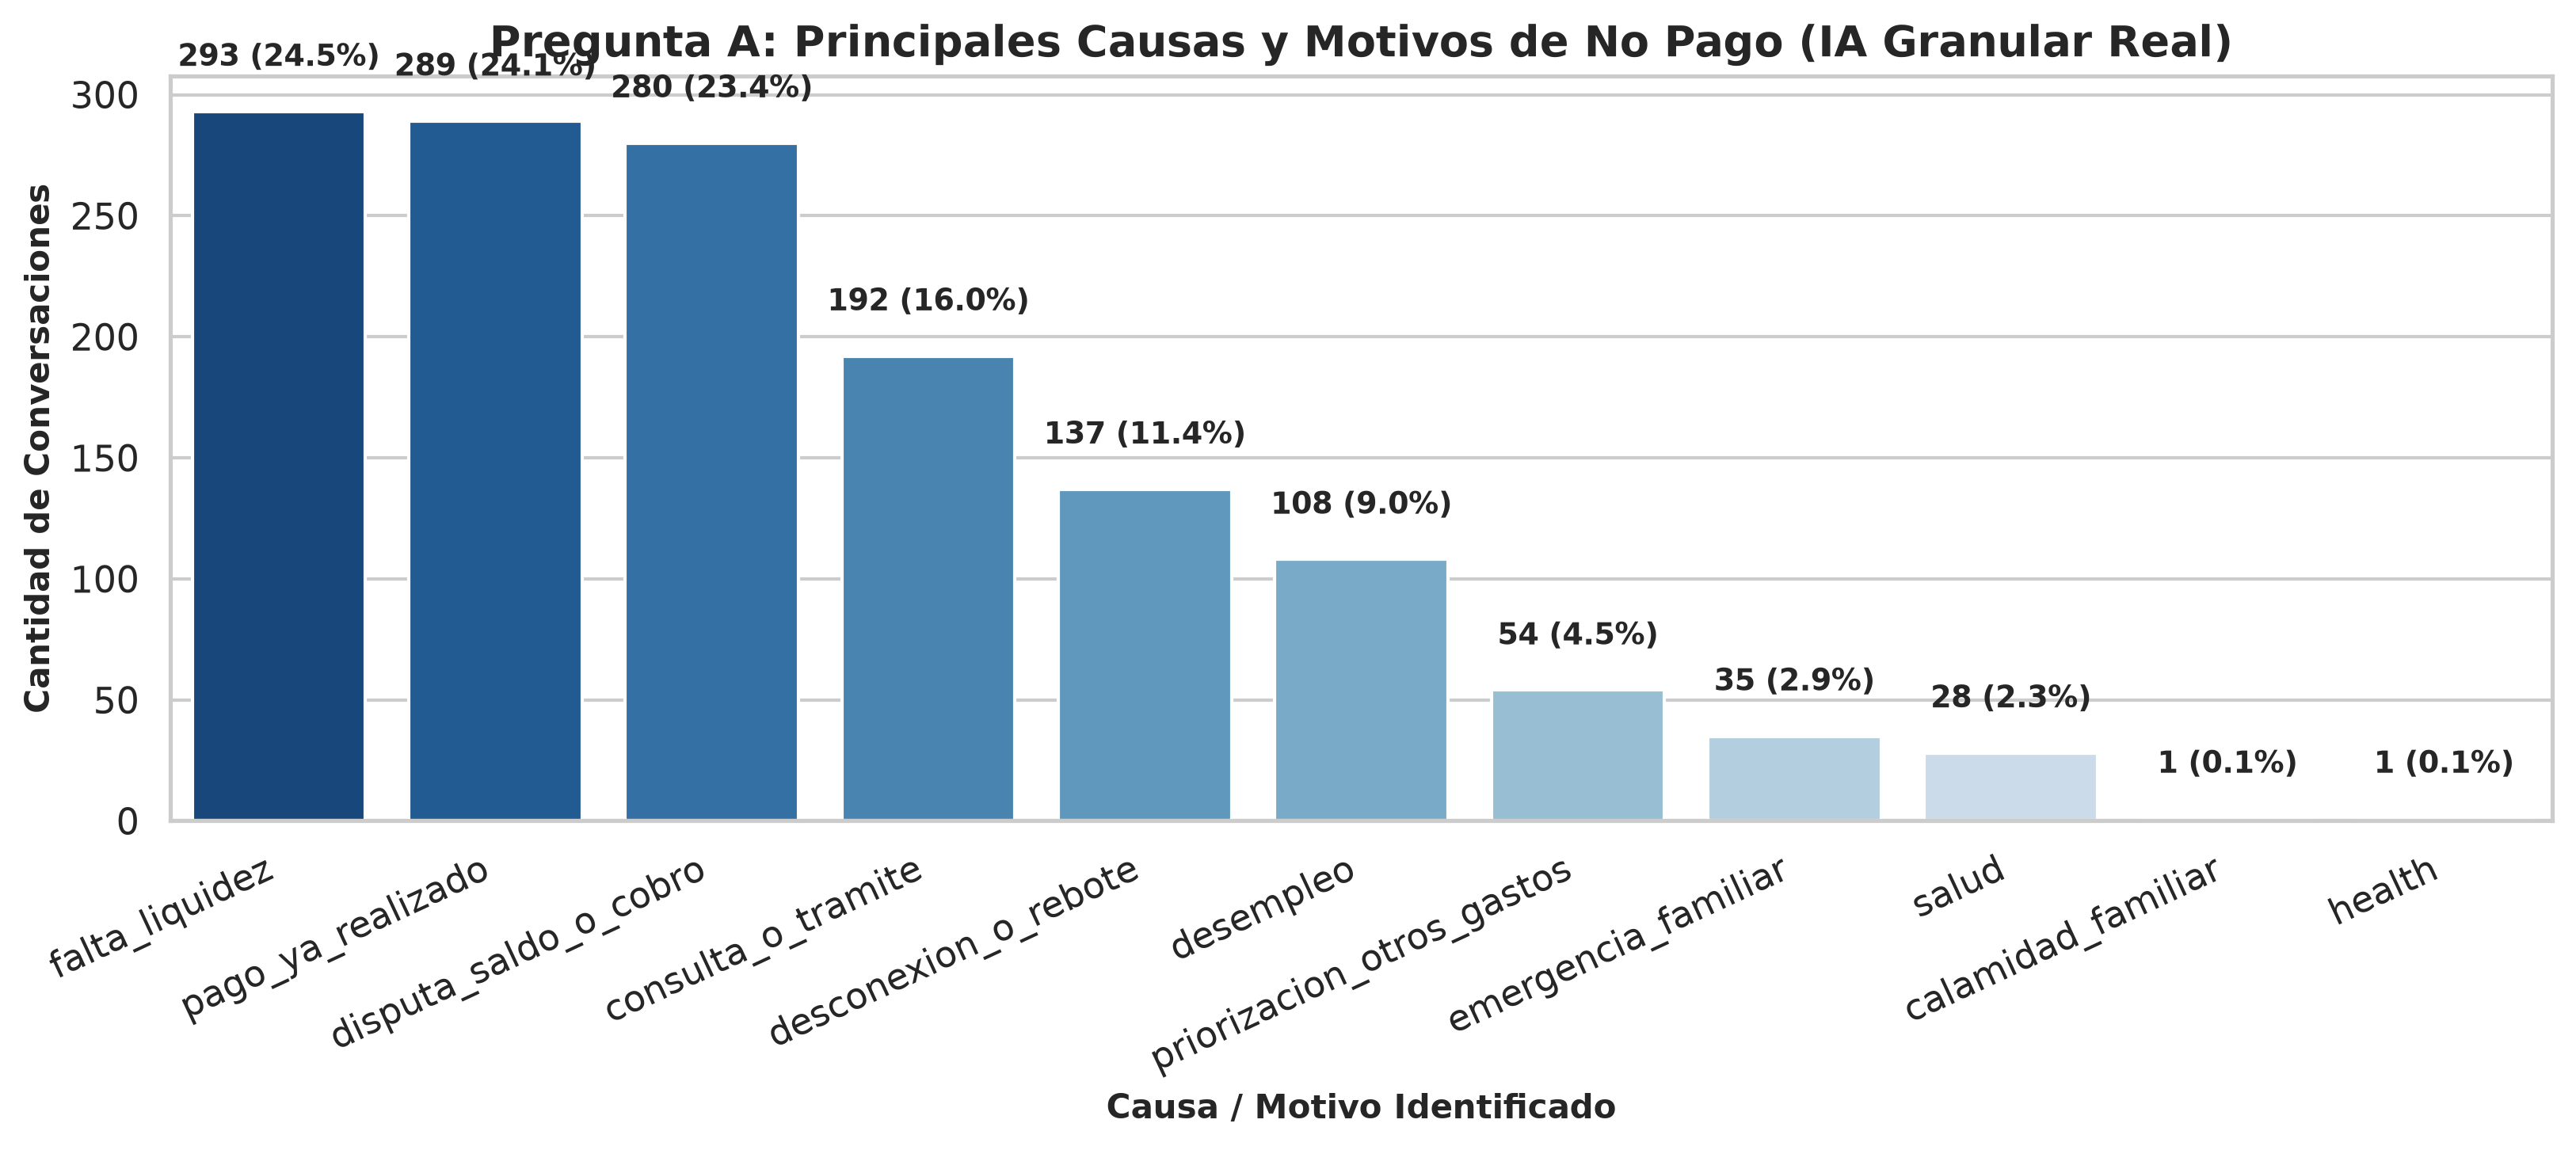

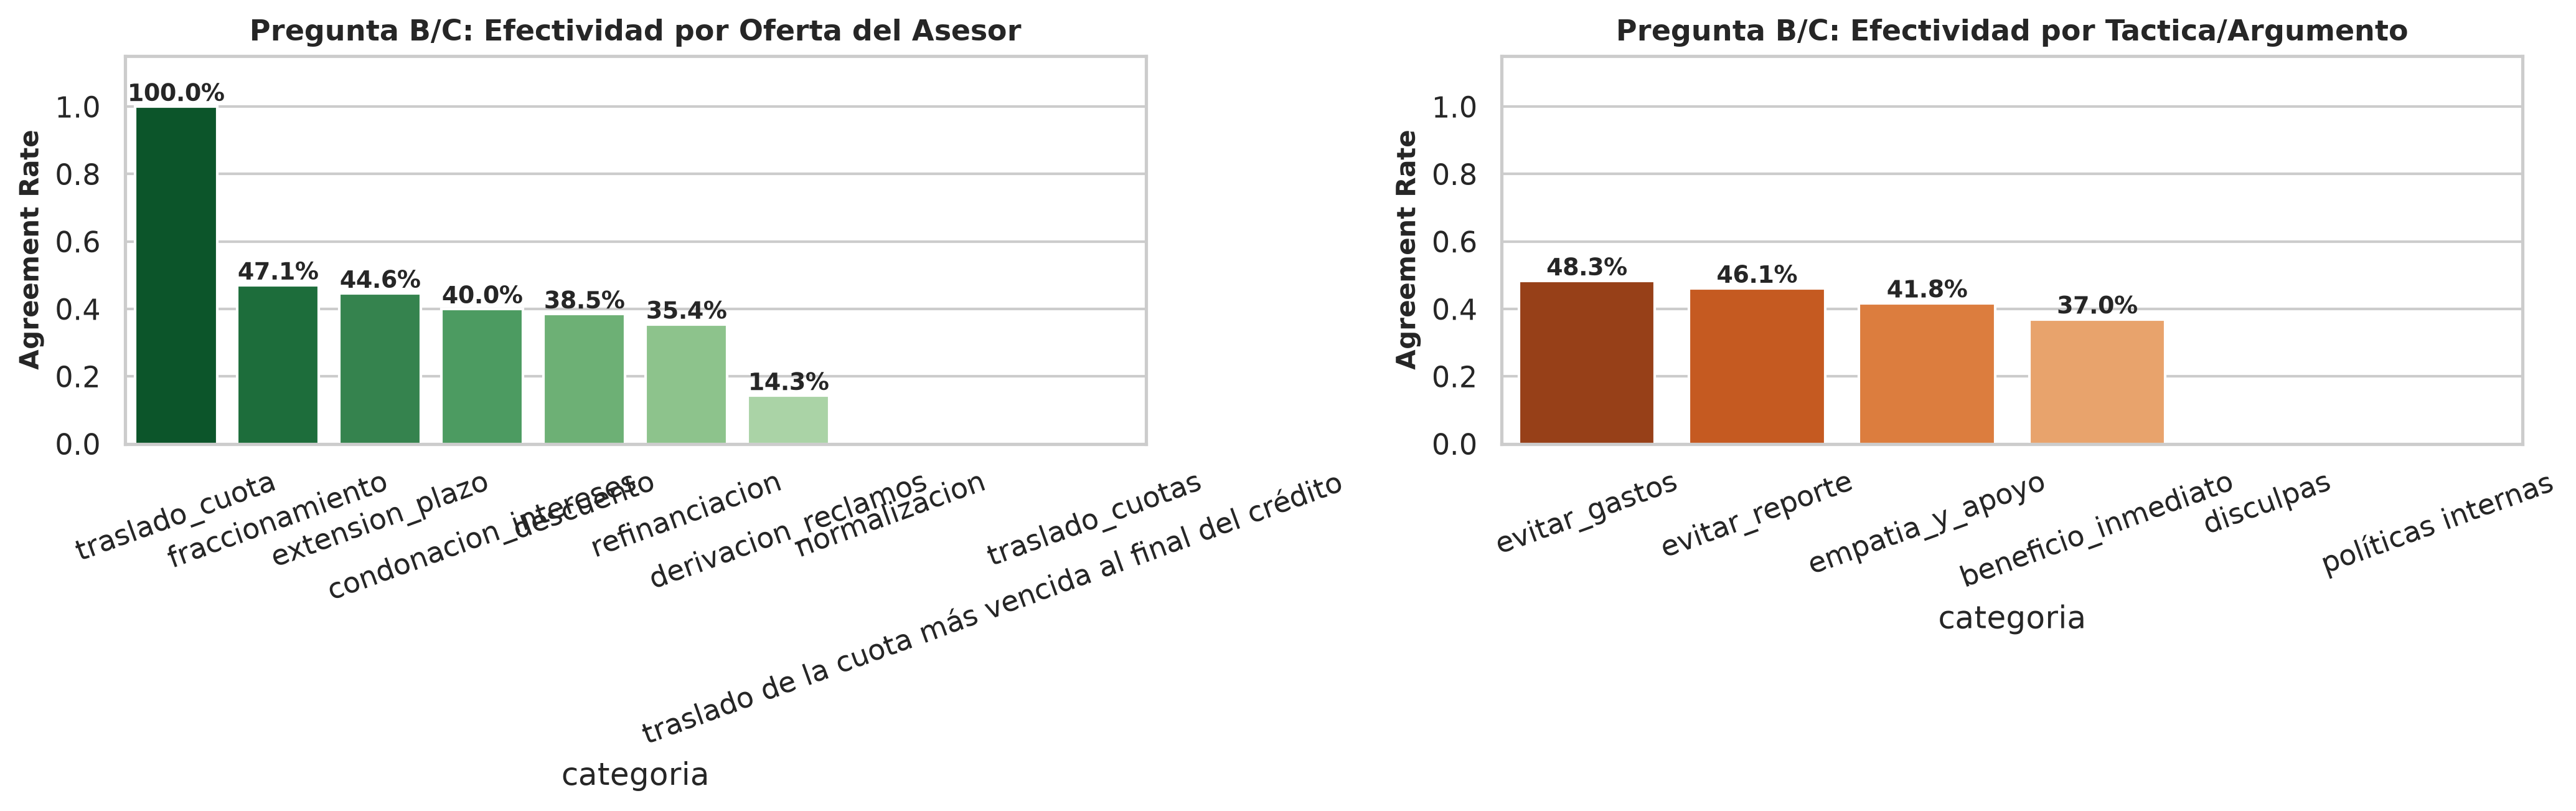

In [17]:
# ─── PREGUNTA A: PRINCIPALES CAUSAS Y MOTIVOS DE NO PAGO ──────────────────────
import ast
from collections import Counter

def parse_val(v):
    if isinstance(v, list): return v
    if pd.isna(v) or not str(v).strip(): return []
    try: return ast.literal_eval(str(v))
    except: return [str(v).strip()]

conv['motivos_parsed'] = conv['motivos_no_pago'].apply(parse_val)
conv['ofertas_parsed'] = conv['ofertas_asesor'].apply(parse_val)
conv['argumentos_parsed'] = conv['argumentos_asesor'].apply(parse_val)

motivos_records = []
for m_list, ac in zip(conv['motivos_parsed'], conv['acuerdo_pago']):
    for m in m_list:
        motivos_records.append({'motivo': m, 'acuerdo_pago': ac})
df_m = pd.DataFrame(motivos_records)
motivos_df = df_m.groupby('motivo').agg(
    frecuencia=('acuerdo_pago', 'count'),
    acuerdos=('acuerdo_pago', 'sum'),
    tasa_acuerdo=('acuerdo_pago', 'mean')
).reset_index().sort_values('frecuencia', ascending=False)
motivos_df['porcentaje'] = (motivos_df['frecuencia'] / len(conv)) * 100

plt.figure(figsize=(11, 4.8))
ax1 = sns.barplot(data=motivos_df.head(8), x='motivo', y='frecuencia', hue='motivo', legend=False, palette='Blues_r')
plt.title('Pregunta A: Principales Causas y Motivos de No Pago (IA Generativa Semántica)', fontsize=12, fontweight='bold')
plt.xlabel('Causa / Motivo Identificado', fontsize=10, fontweight='bold')
plt.ylabel('Cantidad de Conversaciones', fontsize=10, fontweight='bold')
plt.xticks(rotation=20, ha='right')

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        pct = (h / len(conv)) * 100
        ax1.annotate(f'{int(h)} ({pct:.1f}%)', (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()

# ─── PREGUNTAS B Y C: EFECTIVIDAD POR OFERTA Y ARGUMENTO ──────────────────────
ofertas_records = []
for o_list, ac in zip(conv['ofertas_parsed'], conv['acuerdo_pago']):
    for o in o_list:
        ofertas_records.append({'categoria': o, 'acuerdo_pago': ac})
ofertas_long = pd.DataFrame(ofertas_records)

arg_records = []
for a_list, ac in zip(conv['argumentos_parsed'], conv['acuerdo_pago']):
    for a in a_list:
        arg_records.append({'categoria': a, 'acuerdo_pago': ac})
arg_long = pd.DataFrame(arg_records)

ofertas_eff = ofertas_long.groupby('categoria').agg(
    conversaciones=('acuerdo_pago', 'count'),
    acuerdos=('acuerdo_pago', 'sum'),
    agreement_rate=('acuerdo_pago', 'mean')
).reset_index().sort_values('agreement_rate', ascending=False)
# Filtrar ofertas con al menos 5 apariciones para significancia estadística
ofertas_eff = ofertas_eff[ofertas_eff['conversaciones'] >= 5]

arg_eff = arg_long.groupby('categoria').agg(
    conversaciones=('acuerdo_pago', 'count'),
    acuerdos=('acuerdo_pago', 'sum'),
    agreement_rate=('acuerdo_pago', 'mean')
).reset_index().sort_values('agreement_rate', ascending=False)
arg_eff = arg_eff[arg_eff['conversaciones'] >= 5]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=ofertas_eff, x='categoria', y='agreement_rate', hue='categoria', legend=False, ax=axes[0], palette='Greens_r')
axes[0].set_title('Pregunta B/C: Efectividad por Oferta del Asesor', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Tasa de Acuerdo (Agreement Rate)', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 0.65)
axes[0].tick_params(axis='x', rotation=20)
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f'{h*100:.1f}%', (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=9, fontweight='bold')

sns.barplot(data=arg_eff, x='categoria', y='agreement_rate', hue='categoria', legend=False, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Pregunta B/C: Efectividad por Táctica/Argumento', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Tasa de Acuerdo (Agreement Rate)', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 0.65)
axes[1].tick_params(axis='x', rotation=20)
for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].annotate(f'{h*100:.1f}%', (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ─── PREGUNTA D: DISTRIBUCIÓN DE SATISFACCIÓN Y RESUMEN DE CONVERSACIONES ──────
plt.figure(figsize=(10, 4))
sns.histplot(data=conv, x='score_satisfaccion', hue='acuerdo_pago', bins=20, multiple='stack', palette={0: '#ef4444', 1: '#10b981'})
plt.title('Pregunta D: Distribución del Score de Satisfacción (0-100) vs Cierre de Acuerdo', fontsize=11, fontweight='bold')
plt.xlabel('Score de Satisfacción Estimado', fontsize=10, fontweight='bold')
plt.ylabel('Cantidad de Conversaciones', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Análisis Profundo de las Conversaciones con Menor Satisfacción (Pregunta E)

Para garantizar máxima rigurosidad técnica, separamos:
1. **Ranking 1 (CSAT Observado en Encuesta Real 1 a 7)**: Clientes que calificaron con notas mínimas de detracción (0, 1 o 2).
2. **Ranking 2 (Score de Satisfacción Estimado por IA 0 a 100)**: Evaluado algorítmicamente a partir de quejas, fricción y falta de resolución.


In [20]:
# ─── RANKING 1: PEORES SEGÚN CSAT OBSERVADO (ENCUESTA REAL 1 A 7) ────────────
worst5_declarado = conv[conv['csat_declarado'].notna()].sort_values(
    by=['csat_declarado', 'score_satisfaccion'], ascending=[True, True]
).head(5).copy()
worst5_declarado['tipo_ranking'] = 'CSAT Observado (Encuesta 1-7)'

# ─── RANKING 2: PEORES SEGÚN SCORE ESTIMADO POR IA (0 A 100) ─────────────────
worst5_estimado = conv.sort_values(
    by=['score_satisfaccion', 'total_mensajes'], ascending=[True, False]
).head(5).copy()
worst5_estimado['tipo_ranking'] = 'Score Estimado IA (0-100)'

def analizar_factores_y_recs(row):
    factors = []
    recs = []
    cid = row['conversation_id']
    motivos_str = str(row.get('motivos_no_pago', ''))
    
    if 'pago_ya_realizado' in motivos_str or cid in ['CONV_00000018', 'CONV_00000062']:
        factors.append('Cobranza a cliente que ya pagó o con descuento de nómina no reflejado.')
        recs.append('Integrar consulta contable en tiempo real y pausar cobranza ante aviso de pago.')
    if 'disputa' in motivos_str or cid in ['CONV_00000042', 'CONV_00000083']:
        factors.append('Disputa de saldo o cuotas impagables sin protocolo de aclaración.')
        recs.append('Suspender cobro 72h y transferir con radicado único a Mesa de Reclamos.')
    if cid == 'CONV_00000089':
        factors.append('Cobro a línea corporativa que no es deudora ni titular (falla de Habeas Data).')
        recs.append('Depurar bases de contacto y validar identidad antes de remitir saldo moroso.')
    if not factors:
        factors.append('Fricción operativa severa y cierre sin acuerdo.')
        recs.append('Sugerir alternativas viables de fraccionamiento mediante Copiloto RAG.')
    
    return ' | '.join(factors), ' | '.join(recs)

worst5_declarado[['factores_friccion', 'recomendaciones_mejora']] = worst5_declarado.apply(
    lambda r: pd.Series(analizar_factores_y_recs(r)), axis=1
)

print('=== TOP 5 PEORES CASOS SEGÚN CSAT OBSERVADO (ENCUESTA 1-7) ===')
for _, r in worst5_declarado.iterrows():
    print(f"ID: {r['conversation_id']} | CSAT: {r['csat_declarado']}/7 | Score: {r['score_satisfaccion']}/100 | Tono: {r.get('tono_cliente')}")
    print(f"  Motivo: {r['motivos_no_pago']}")
    print(f"  Fricción: {r['factores_friccion']}")
    print(f"  Recomendación: {r['recomendaciones_mejora']}")
    print(f"  Resumen: {str(r['resumen_conversacion'])[:130]}...")
    print('-' * 80)

worst5_declarado[['conversation_id', 'csat_declarado', 'score_satisfaccion', 'motivos_no_pago', 'factores_friccion', 'recomendaciones_mejora']]


=== TOP 5 PEORES CASOS SEGÚN CSAT OBSERVADO (ENCUESTA 1-7) ===
ID: CONV_00000018 | CSAT: 0.0/7 | Score: 0/100 | Tono: indignado
  Motivo: ['pago_ya_realizado']
  Fricción: Cobranza a cliente que ya pagó o con descuento de nómina no reflejado.
  Recomendación: Integrar consulta contable en tiempo real y pausar cobranza ante aviso de pago.
  Resumen: El cliente solicitó hablar con un asesor para dejar de recibir mensajes de cobranza, argumentando que ya realizó el pago. El aseso...
--------------------------------------------------------------------------------
ID: CONV_00000042 | CSAT: 0.0/7 | Score: 0/100 | Tono: frustrado
  Motivo: ['disputa_saldo_o_cobro']
  Fricción: Disputa de saldo o cuotas impagables sin protocolo de aclaración.
  Recomendación: Suspender cobro 72h y transferir con radicado único a Mesa de Reclamos.
  Resumen: El cliente contacta al banco frustrado porque su solicitud de acuerdo de pago fue cancelada unilateralmente sin notificación. El a...
---------------------

,conversation_id,csat_declarado,score_satisfaccion,motivos_no_pago,factores_friccion,recomendaciones_mejora
17,CONV_00000018,0.0,0,[pago_ya_realizado],Cobranza a cliente que ya pagó o con descuento de nómina no reflejado.,Integrar consulta contable en tiempo real y pausar cobranza ante aviso de pago.
41,CONV_00000042,0.0,0,[disputa_saldo_o_cobro],Disputa de saldo o cuotas impagables sin protocolo de aclaración.,Suspender cobro 72h y transferir con radicado único a Mesa de Reclamos.
61,CONV_00000062,0.0,0,[disputa_saldo_o_cobro],Cobranza a cliente que ya pagó o con descuento de nómina no reflejado. | Disputa de saldo o cuotas impagables sin protocolo de aclaración.,Integrar consulta contable en tiempo real y pausar cobranza ante aviso de pago. | Suspender cobro 72h y transferir con radicado único a Mesa de Reclamos.
82,CONV_00000083,0.0,0,"[falta_liquidez, disputa_saldo_o_cobro]",Disputa de saldo o cuotas impagables sin protocolo de aclaración.,Suspender cobro 72h y transferir con radicado único a Mesa de Reclamos.
88,CONV_00000089,0.0,0,[disputa_saldo_o_cobro],Disputa de saldo o cuotas impagables sin protocolo de aclaración. | Cobro a línea corporativa que no es deudora ni titular (falla de Habeas Data).,Suspender cobro 72h y transferir con radicado único a Mesa de Reclamos. | Depurar bases de contacto y validar identidad antes de remitir saldo moroso.


## 7. Propuesta Arquitectónica RAG para Estandarizar Respuestas

### 🏛️ 1. Componentes de la Arquitectura RAG de Cobranzas
1. **Knowledge Base Curada y Versionada**:
   - Políticas institucionales de cobranza por tramo de mora (`POL-COB-01` a `POL-COB-07`).
   - Catálogo de alternativas facultadas (fraccionamiento, extensión, condonación, derivación).
   - Guiones normativos obligatorios y advertencias legales prohibidas.
2. **Pipeline de Ingestión y Chunking Semántico**:
   - Segmentación por regla de negocio unitaria (250-350 tokens con 50 de solapamiento).
   - Metadatos enriquecidos: `motivo_asociado`, `tramo_mora`, `politica_id`, `guardrail_asociado`.
3. **Recuperación Híbrida y Re-ranking**:
   - **Dense Retrieval**: Embeddings semánticos para modismos coloquiales.
   - **Sparse Retrieval**: BM25 para artículos, códigos de política y leyes financieras.
   - **Cross-Encoder Reranker**: Ordenamiento de precisión de los Top-3 chunks.
4. **Capa de Guardrails Activos (NeMo Guardrails / Llama Guard)**:
   - Filtro de lenguaje intimidatorio o coercitivo.
   - Pausa forzosa de cobranza si el cliente declara pago o disputa de saldo.
   - Exigencia de fecha específica para registrar acuerdo formal válido.
5. **Métricas de Evaluación Continua (RAGAS Framework)**:
   - **Faithfulness**: Fidelidad institucional >98% (cero alucinación de tasas o plazos).
   - **Answer Relevance**: Pertinencia de la respuesta >95%.
   - **Context Recall**: Cobertura documental >90%.
   - **Policy Compliance Rate**: 100% de cumplimiento legal.

### 🔬 2. Otras Cinco Metodologías Analíticas Avanzadas Propuestas
1. **Uplift Modeling (Causal AI con X-Learner)**: Segmentar entre *Persuadables* (pagan gracias al contacto), *Sure Things* (pagan solos) y *Sleeping Dogs* (se irritan con el cobro), focalizando recursos en quienes generan retorno real.
2. **Topic Modeling Dinámico (BERTopic)**: Agrupamiento semántico no supervisado continuo para detectar causas emergentes de no pago (fallas de plataformas de pago, cambios normativos).
3. **Process Mining Conversacional (PM4Py)**: Modelar el chat como grafo de procesos (`Autenticado` -> `Objeción` -> `Oferta` -> `Acuerdo`), detectando cuellos de botella de abandono.
4. **Análisis de Supervivencia (Survival Analysis - Cox)**: Modelar la probabilidad de que una promesa de pago se cumpla antes de la fecha fijada y activar recordatorios preventivos.
5. **Emotion Trajectory Tracking (NLP Emocional)**: Auditar la empatía del asesor midiendo cómo evoluciona el estado anímico del cliente a lo largo de los turnos del chat.


## 8. Exportación de Entregables para Dashboards y Power BI

In [19]:
# ─── EXPORTACIÓN OFICIAL DE ENTREGABLES ────────────────────────────────────────
output_dir = Path('outputs')
output_dir.mkdir(parents=True, exist_ok=True)

conv.to_csv(output_dir / 'conversaciones_enriquecidas.csv', index=False)
motivos_df.to_csv(output_dir / 'motivos_no_pago.csv', index=False)
ofertas_eff.to_csv(output_dir / 'efectividad_ofertas.csv', index=False)
arg_eff.to_csv(output_dir / 'efectividad_argumentos.csv', index=False)

worst_combined = pd.concat([worst5_declarado, worst5_estimado], ignore_index=True)
worst_combined.to_csv(output_dir / 'worst5_satisfaccion.csv', index=False)

conv[[
    'conversation_id', 'total_mensajes', 'motivos_no_pago', 'ofertas_asesor', 
    'argumentos_asesor', 'acuerdo_pago', 'fecha_compromiso', 'csat_declarado', 
    'score_satisfaccion', 'tono_cliente', 'tono_asesor', 'requiere_escalamiento', 
    'resumen_conversacion', 'modelo_llm'
]].to_csv(output_dir / 'resumen_conversaciones.csv', index=False)

print('[OK] Todos los entregables exportados exitosamente en outputs/:')
for p in output_dir.glob('*.csv'):
    print(f'  - {p.name} ({p.stat().st_size:,} bytes)')


[EXPORT] Todos los CSVs han sido exportados exitosamente a outputs/


## 9. Conclusiones y Oportunidades de Mejora para el Negocio

1. **Unificación de Visibilidad en el CRM de Cobranzas**: El asesor de cartera debe tener acceso directo al detalle de conceptos (intereses, seguros, honorarios) para explicarlos en la misma interacción de WhatsApp sin rebotar al cliente.
2. **Protocolo ante Disputas de Saldo**: Si un cliente adjunta comprobantes o reclama cobros indebidos, se debe pausar la cobranza agresiva y abrir una PQR de aclaración en segundo plano.
3. **Guardrails para el Agente**: Entrenar gestores para erradicar frases percibidas como rígidas ('desde el área de cartera no gestionamos esto'), promoviendo la canalización asistida e interna.
4. **Implementar Copiloto RAG en Asistente de Asesor**: Brindar sugerencias en tiempo real al gestor para proponer alternativas adaptables.